# Project Description — Indoor Classroom Temperature Prediction Using Neural Networks

This project develops a machine learning model to predict **indoor classroom temperature** using environmental conditions, classroom characteristics, and occupancy-related variables.

The workflow combines **data preprocessing, feature engineering, and neural network modeling**. Data such as timestamp, classroom grid location, number of occupants, ventilation status, AC/fan usage, device count, room height, and outdoor weather conditions are transformed into numerical features for training.

A preprocessing pipeline handles missing values, scales numerical features, and encodes categorical variables. The processed data is used to train a **feed-forward neural network** that learns relationships between environmental factors and classroom temperature.

Model performance is evaluated using **Mean Absolute Error (MAE)** and **R² score**, and the trained model along with the preprocessing pipeline is saved for future predictions.

### Import Libaries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

### Data loading and preprocessing

The dataset contains environmental and indoor conditions used to predict **indoor temperature**.

Key variables include:

- Timestamp
- Number of people
- Windows status
- AC/Fan status
- Number of devices
- Room height
- Outside temperature
- Outside humidity
- Precipitation

The dataset is loaded into a Pandas DataFrame.

In [23]:
file_path = "./dataset/temperature_dataset.csv" 
df = pd.read_csv(file_path)

### Exploratory Data Analysis

##### Preview Data

The commands below does the following:
- Inspect first few rows
- View column names
- Check data types and null values
- Generate statistical summaries

In [24]:
df.head(), df.columns, df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             324 non-null    object 
 1   Grid Row              324 non-null    object 
 2   Grid Column           324 non-null    object 
 3   People                324 non-null    int64  
 4   Temp (°C)             324 non-null    float64
 5   Humidity (%)          324 non-null    float64
 6   Windows Open          324 non-null    int64  
 7   AC/Fan On             324 non-null    object 
 8   No of AC/Fans         324 non-null    int64  
 9   No of Devices         324 non-null    int64  
 10  Height                324 non-null    object 
 11  Area                  324 non-null    float64
 12  Outside Temp (°C)     324 non-null    float64
 13  Outside Humidity (%)  324 non-null    float64
 14  Precipitation         324 non-null    object 
dtypes: float64(5), int64(4)

(             Timestamp Grid Row Grid Column  People  Temp (°C)  Humidity (%)  \
 0  2026-03-06 08:30:00        A          G1       0       26.4          85.0   
 1  2026-03-06 08:30:00        A          G2       0       26.4          84.0   
 2  2026-03-06 08:30:00        A          G3       3       26.5          86.0   
 3  2026-03-06 08:30:00        B          G1       0       26.5          85.0   
 4  2026-03-06 08:30:00        B          G2       1       26.4          85.0   
 
    Windows Open AC/Fan On  No of AC/Fans  No of Devices Height  Area  \
 0             0       off              0              0    0ft  12.5   
 1             0       off              0              0    0ft  12.5   
 2             0       off              0              0    0ft  12.5   
 3             0       off              0              0    3ft  12.5   
 4             0       off              0              0    3ft  12.5   
 
    Outside Temp (°C)  Outside Humidity (%) Precipitation  
 0          

##### Distribution Analysis

- Visualizes feature distributions.
- Helps identify skewness and outliers.

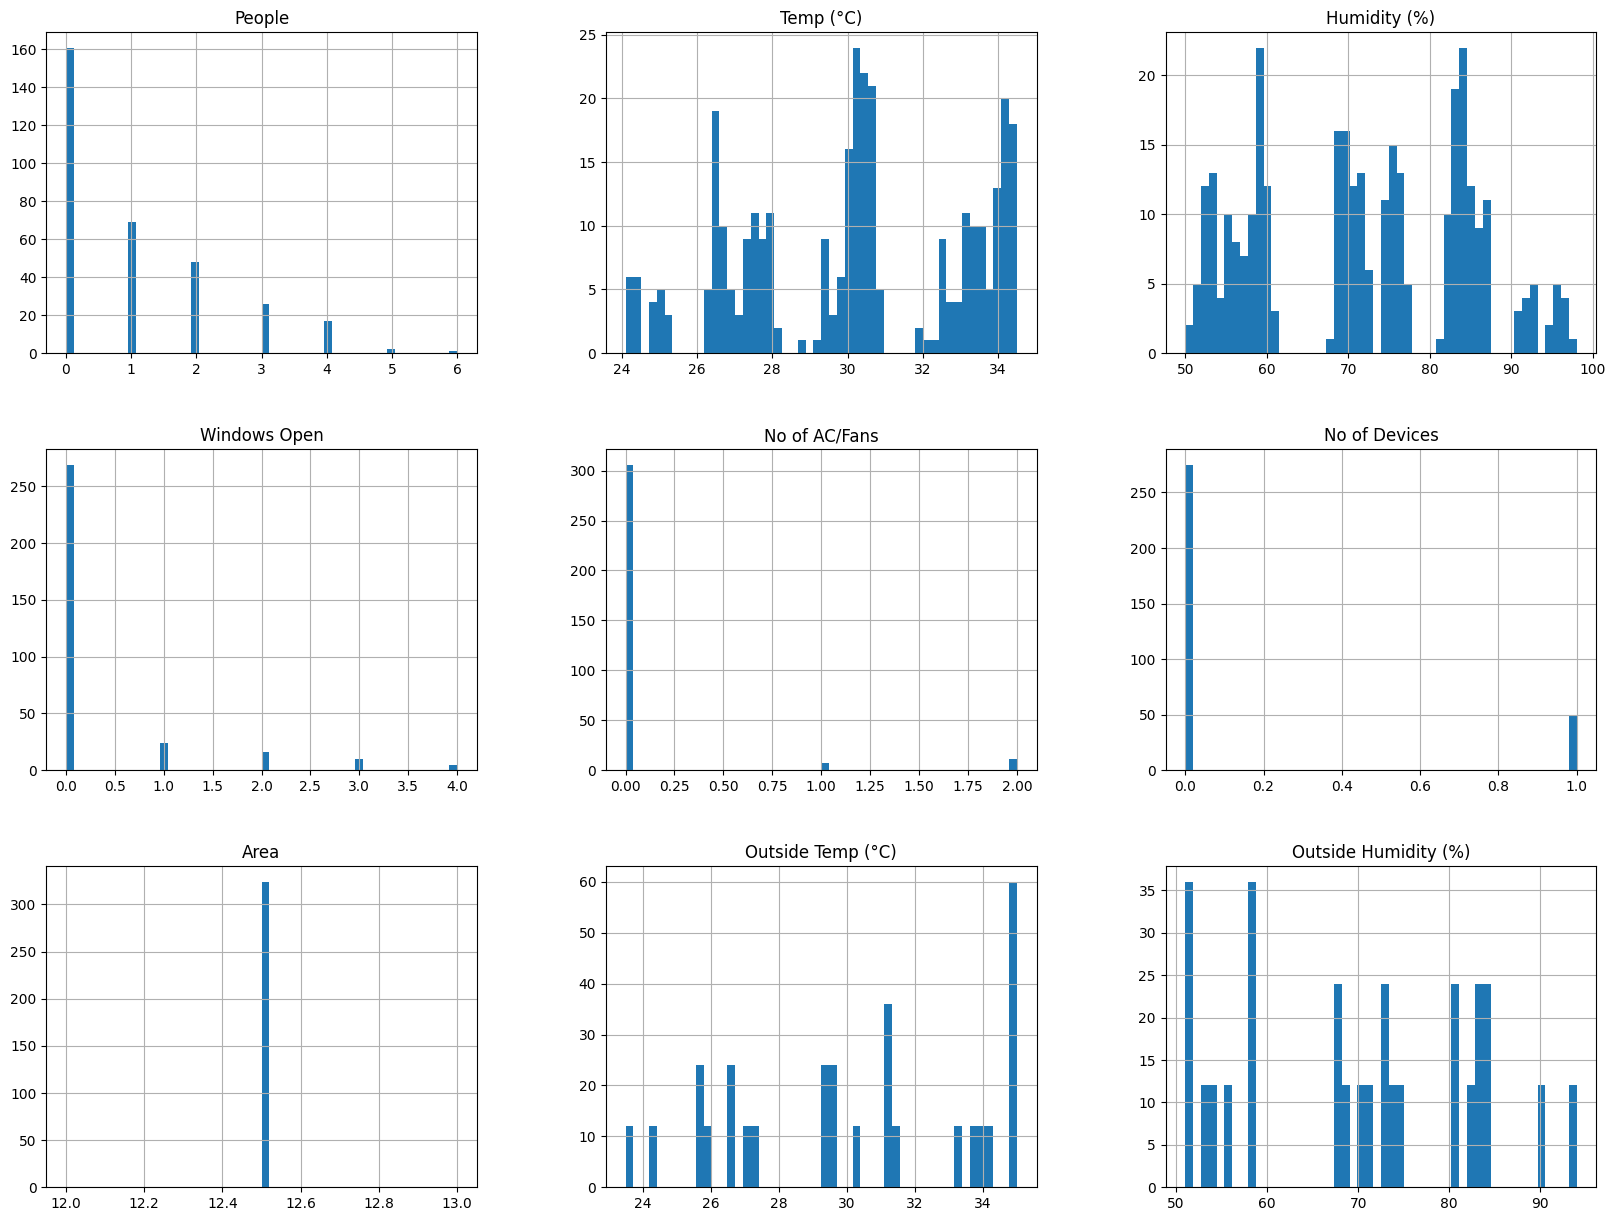

In [25]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

#### Scatter Plot

This plot visualizes:
- Timestamp
- Humidity (%)


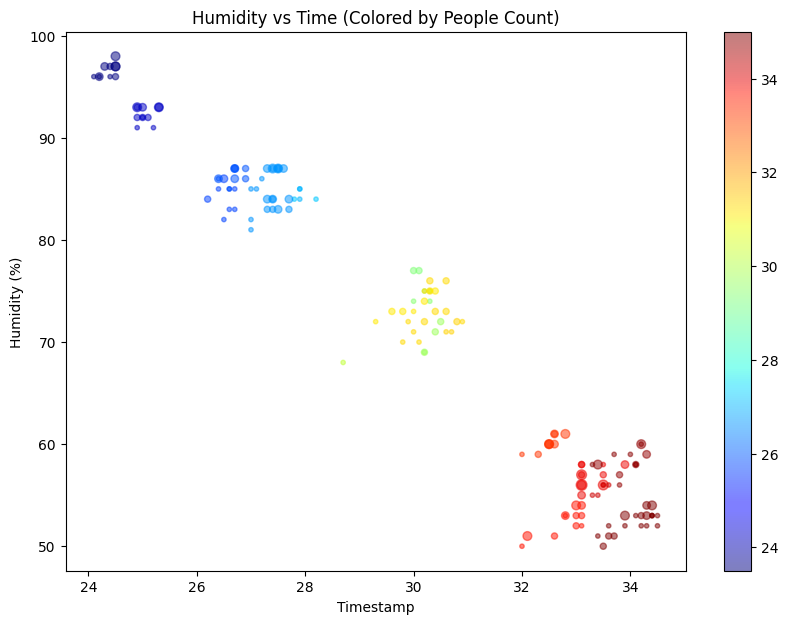

In [26]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.plot(
    kind="scatter",
    x="Temp (°C)",
    y="Humidity (%)",
    alpha=0.5,
    s=df["People"] * 10,
    c=df["Outside Temp (°C)"],
    cmap="jet",
    colorbar=True,
    figsize=(10,7)
)

plt.xlabel("Timestamp")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time (Colored by People Count)")
plt.show()

### Feature Engineering

Some variables require transformation before they can be used by the model.

The following transformations are applied:

1. Extract **Hour** from the timestamp.
2. Convert **AC/Fan On** from text (`on/off`) to numeric (`1/0`).
3. Convert **Precipitation** from text (`Yes/No`) to numeric (`1/0`).
4. Convert **Height** from text (e.g. `10ft`) to numeric values.

In [27]:
df['Hour'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M', errors='coerce').dt.hour
df['AC/Fan On'] = df['AC/Fan On'].map({'on': 1, 'off': 0})
df['Precipitation'] = df['Precipitation'].map({'Yes': 1, 'No': 0})
df['Height'] = df['Height'].str.replace('ft', '').astype(float)

### Feature Selection

We separate the dataset into:

- **Input features (X)** – variables used to predict temperature
- **Target variable (y)** – indoor temperature

In [29]:
features = [
    'Hour', 'Grid Row', 'Grid Column', 'People', 'Humidity (%)', 'Windows Open', 
    'AC/Fan On', 'No of AC/Fans', 'No of Devices', 'Height', 
    'Outside Temp (°C)', 'Outside Humidity (%)', 'Precipitation'
]
X = df[features].copy()
y = df['Temp (°C)']

### Data Preprocessing Pipeline

Before training the neural network, the data must be transformed.

Two types of features exist:

#### Numeric Features
- Missing values filled using **median**
- Features scaled using **StandardScaler**

#### Categorical Features
- Missing values filled using **most frequent value**
- Encoded using **One-Hot Encoding**

The preprocessing steps are combined using a **ColumnTransformer**.

In [30]:
numeric_features = [
    'Hour', 'People', 'Windows Open', 'AC/Fan On', 'No of AC/Fans', 
    'No of Devices', 'Height', 'Outside Temp (°C)', 'Outside Humidity (%)', 'Precipitation'
]
categorical_features = ['Grid Row', 'Grid Column']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


### Train-Test Split

The dataset is divided into:

- **Training set (80%)** – used to train the model
- **Test set (20%)** – used to evaluate model performance

In [31]:
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((259, 17), (65, 17), (259,), (65,))

### Neural Network Architecture

The neural network contains:

- Input layer (number of processed features)
- Hidden layer with **64 neurons (ReLU activation)**
- Hidden layer with **32 neurons (ReLU activation)**
- Output layer with **1 neuron** for temperature prediction


In [32]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model.summary()

c:\Users\A0X0P\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation
- optimizer="adam" -> adaptive gradient decent
- loss="mse"

Loss function:

$$MSE = \frac{1}{n}∑(y−\hat{y})^2$$

In [33]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### Model Training

The model is trained using:

- **1000 epochs**
- **Batch size of 16**
- **20% validation split**

In [35]:
history = model.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=1000, 
    batch_size=16, 
)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3604 - mae: 0.4655 - val_loss: 0.4445 - val_mae: 0.5505
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3631 - mae: 0.4657 - val_loss: 0.4523 - val_mae: 0.5490
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3535 - mae: 0.4618 - val_loss: 0.4401 - val_mae: 0.5457
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3589 - mae: 0.4691 - val_loss: 0.4257 - val_mae: 0.5374
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3459 - mae: 0.4573 - val_loss: 0.4445 - val_mae: 0.5495
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3424 - mae: 0.4537 - val_loss: 0.4335 - val_mae: 0.5465
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3372 - mae: 0.4524 - val_loss: 0.4300 - val_mae: 0.5412
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3366 - mae: 0.4523 - val_loss: 0.4241 - val_mae: 0.5301
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

### Model Evaluation

Model performance is evaluated using:

- **Mean Absolute Error (MAE)** – average prediction error
- **R² Score** – proportion of variance explained by the model

In [38]:
preds = model.predict(X_test)
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, preds):.2f} °C")
print(f"R-squared Score (Accuracy proxy): {r2_score(y_test, preds):>2.2f}\n")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
Mean Absolute Error (MAE): 0.42 °C
R-squared Score (Accuracy proxy): 0.95



### Learning Curve

The learning curve shows how training and validation error evolve during training.

This helps detect:

- Overfitting
- Underfitting
- Convergence behavior

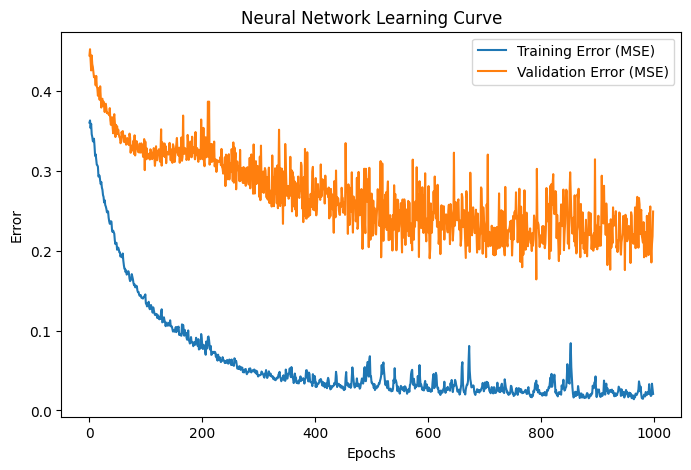

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Error (MSE)')
plt.plot(history.history['val_loss'], label='Validation Error (MSE)')
plt.title('Neural Network Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.show()

### Saving the Model

The trained model and preprocessing pipeline are saved for future inference.

Saved artifacts:

- Neural network model (`.keras`)
- Data preprocessing pipeline (`.joblib`)

In [42]:
model.save('model/temperature_nn_model.keras')
joblib.dump(preprocessor, 'preprocessor/nn_preprocessor.joblib')
print("✅ Success! Model and Preprocessor saved.")

✅ Success! Model and Preprocessor saved.
